# Maximum Likelihood 

#### 🎯 Learning Goals

1. Introduction to maximum likelihood estimation
2. Understand log-likelihood as a loss function
3. Use gradient descent to solve for argmin.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import pi

# Use a nicer style for plots
plt.style.use("seaborn-v0_8-muted")

#### 📝 Notation and Terminology
Let us briefly refresh notation before we dive into the concepts of interest.

+ We have a dataset $\mathcal{D} = \{(\mathbf{x}^{(i)}, y^{(i)})\}_{i=1}^n$ consisting of $n$ observations.
+ Each observation $(\mathbf{x}^{(i)}, y^{(i)})$ consists of 
    1. A vector $\mathbf{x}^{(i)} \in \mathcal{X}$, also called *feature*, *covariate*, or *independent variable*, 
    2. A scalar $y^{(i)} \in \mathcal{Y}$, also called *label*, *target*, *response*, *outcomes*, or *dependent variable*.
    
In this notebook
+ We assume that there exist a linear relationship between $y^{(i)}$ and $\mathbf{x}^{(i)}$, which can be written in the general form $$y^{(i)} = \mathbf{x}^{(i)\top}\boldsymbol{\beta} + \epsilon^{(i)},$$ where $\beta$ are the *true* coefficients and $\epsilon^{(i)}$ is the *error* term or *noise* term.
+ $\epsilon^{(i)}$ is assumed to be independently and identically distributed across observations according to a known distribution function $p$. For simplicity, we assume and guarantee by the data preprocessing that $\text{Var}(\epsilon^{(i)}) = 1$
+ We want to estimate ${\beta}$ to make predictions on $y$.


<!-- + We assume that the data is generated by an unknown distribution $p_\text{data}$, i.e., $(\mathbf{x}^{(i)}, y^{(i)}) \sim p_\text{data}$. -->

## Likelihood function

The likelihood function or simply likelihood is the joint probability (or probability density) of observed data viewed as a function of the parameters, $\beta$,  of a statistical model.

+ $\mathcal{L}(y; \beta) = \prod_{i=1}^n p(\epsilon_i) = \prod_{i=1}^n p(y^{(i)}-\mathbf{x}^{(i)\top}\boldsymbol{\beta})$

#### ➡️ ✏️ Task 1 

Assume the following statistical model
+ $y^{(i)} = \beta_0 + \beta_1x^{(i)} + \epsilon^{(i)}$
+ $\epsilon^{(i)} \sim N(0, 1)$.

The likelihood for a sample of observations ranging from $i=1, \ldots, n$ is
+  $\mathcal{L}(\mathbf{y}; \beta_0, \beta_1) = \prod_{i=1}^n \frac{1}{\sqrt{2 \pi}} \exp({-\frac{1}{2}(y^{(i)}-\beta_0-\beta_1x^{(i)})^2 })$

In [2]:
# Complete the code to compute the likelihood

def likelihood(y, x, beta_0, beta_1):
    # your code here
    return

In [3]:
# TODO: Remove solution

def likelihood(y, x, beta_0, beta_1):
    const = 1/((2*pi)**0.5)
    lik = np.prod(const*np.exp(-0.5*(y - beta_0 - beta_1*x)**2))
    return lik

## Log-Likelihood

The log-likelihood is a positive monotone transformation of the likelihood function 

+ $ \log \mathcal{L}(y; \beta) =  \sum_{i=1}^n \log (p(\epsilon_i)) = \sum_{i=1}^n \log (p(y^{(i)}- \mathbf{x}^{(i)\top}\boldsymbol{\beta}))$

#### ➡️ ✏️ Task 2

1. First, derive $ \log \mathcal{L}(y; \beta)$ for the statistical model from Task 1.
2. Second, adapt the function below to compute the log-likelihood.

In [4]:
# Adapt your previous code to compute the log-likelihood

def loglikelihood(y, x, beta_0, beta_1):
    # your code here
    pass

In [5]:
# TODO: Remove solution

def loglikelihood(y, x, beta_0, beta_1):
    const = -0.5*np.log((2*pi))*len(y)
    loglik = const - np.sum(0.5*(y - beta_0 - beta_1*x)**2)
    return loglik

## Maximum Likelihood Estimation

In maximum likelihood estimation, the arg max (over the parameters $\beta$) of the likelihood function serves as a point estimate for the unknown parameters. 

+  $\arg \max_{\beta} \mathcal{L}(y; \beta) = \prod_{i=1}^n p(\epsilon_i) = \prod_{i=1}^n p(y^{(i)}-\mathbf{x}^{(i)\top}\boldsymbol{\beta})$

#### ➡️ ✏️ Task 3

Compute the log-likelihood for different values of $\beta_0$ and plot the log-likelihood as a function of $\beta_0$. Discuss with your neighbour which of the $\beta_0$ you would pick if you had to pick one.

In [6]:
np.random.seed(123)
n = 100
x = np.zeros((n, 1))
b_0 = 40
b_1 = 0
e = np.random.normal(size=(n, 1))
y = b_0 + x*b_1 + e

In [7]:
# TODO: Remove solution 

betas = np.linspace(0, 100, num=1000)
result = np.zeros((1000, 2))

for i, beta in enumerate(betas):
    result[i, 0] = beta
    result[i, 1] = loglikelihood(y, x, beta, b_1)

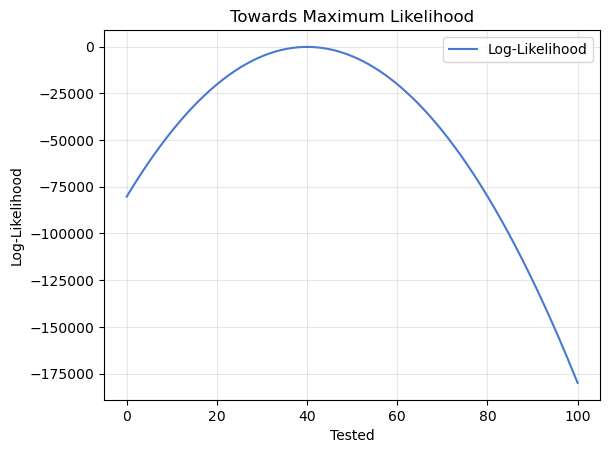

In [8]:
fig, ax = plt.subplots()
ax.plot(result[:, 0], result[:, 1], label='Log-Likelihood')

# Add some plot aesthetics
ax.set_xlabel("Tested")
ax.set_ylabel("Log-Likelihood")
ax.set_title("Towards Maximum Likelihood")
ax.grid(alpha=0.3)

ax.legend()

#### ➡️ ✏️ Task 3

1. Discuss why the $\arg \max$ of $\mathcal{L}$ is equivalent to the $\arg \max$ of $\log \mathcal{L}$.
2. Discuss why the $\arg \max$ of $\log \mathcal{L}$ is equivalent to the $\arg \min$ of $- \log \mathcal{L}$.
3. Repeat Task 2 but now plot on the y-axis the negative log-likelihood. Interpret the plot and convince yourself that the best pick for $\beta_0$ is still the same.

## Minimizing the Negative Log-Likelihood

In general you can use gradient or stochastic gradient descent to find the parameters, which minimize the negativ log-likelihood. For some likelihood functions it is also convenient to derive the analytical solution.

#### ➡️ ✏️ Task 4

Still consider the statistical model $y^{(i)} = \beta_1x^{(i)} + \varepsilon^{(i)}$, where $\varepsilon^{(i)} \sim N(0, 1)$. Using gradient descent and an appropriate learning rate, solve
+ $\arg \min_{\beta_0, \beta_1} \log \mathcal{L}(\mathbf{y}; \beta_1) =   \sum_{i=1}^n  0.5\log(2\pi) + 0.5(y^{(i)}-\beta_1x^{(i)})^2 $

for the data provided below. Compare your estimates with estimates, which resulted from MSE loss. Do you find the result intuitive?

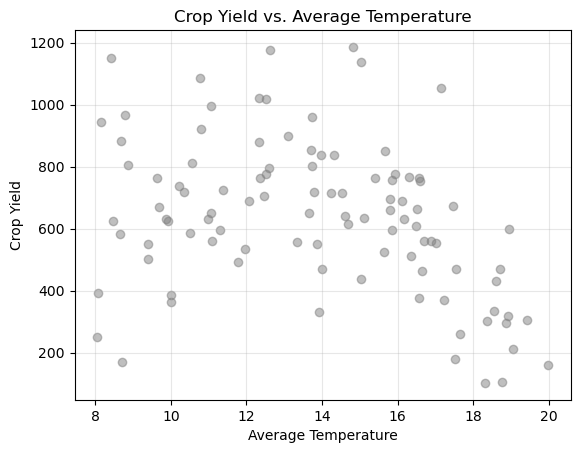

In [9]:
crops = pd.read_csv("data/us_crops.csv")
crops.head()

fig, ax = plt.subplots()

# Plot the individual observations
ax.scatter(crops["temp"], crops["yield"], alpha=.5, color="gray")

ax.set_title("Crop Yield vs. Average Temperature")
ax.set_xlabel("Average Temperature")
ax.set_ylabel("Crop Yield")
ax.grid(alpha=0.3)

First, we standardize the data

In [10]:
crops["yield"] = (crops["yield"] - crops["yield"].mean()) / (crops["yield"].std())
crops["temp"] = (crops["temp"] - crops["temp"].mean()) / (crops["temp"].std())

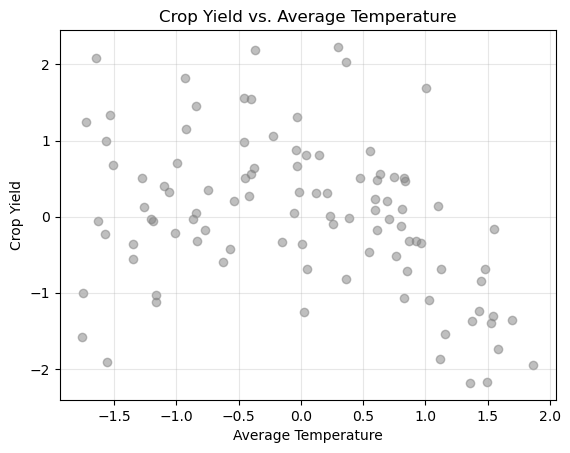

In [11]:
fig, ax = plt.subplots()

# Plot the individual observations
ax.scatter(crops["temp"], crops["yield"], alpha=.5, color="gray")

ax.set_title("Crop Yield vs. Average Temperature")
ax.set_xlabel("Average Temperature")
ax.set_ylabel("Crop Yield")
ax.grid(alpha=0.3)

In [12]:
# Write gradient descent

def update(y, x, beta_0, beta_1, eta):
    first = (y - beta_0 - beta_1*x).mean()
    second = (x*(y - beta_0 - beta_1*x)).mean()
    beta_0_up = beta_0 + eta*first
    beta_1_up = beta_1 + eta*second
    slope = max(first, second)
    return beta_0_up, beta_1_up, slope

beta_0 = 10
beta_1 = -10
max_iter = 10000

# Write the function to update
for iter in range(0, max_iter):
    beta_0_old = beta_0
    beta_1_old = beta_1
    beta_0, beta_1, slope = update(crops["yield"], crops["temp"], beta_0, beta_1, 1)
    print(f"Iteration {iter}, beta_0 {beta_0}, beta_1 {beta_1}.")
    if abs(slope) < 0.0005:
       break

Iteration 0, beta_0 8.881784197001252e-15, beta_1 -0.45677999708872363.
Iteration 1, beta_0 2.0622392682412302e-16, beta_1 -0.3613477970596033.
Iteration 2, beta_0 1.0297318553398345e-16, beta_1 -0.360393475059312.
Iteration 3, beta_0 9.631184738623252e-17, beta_1 -0.36038393183930917.


___
#### 🤔 Pause and ponder

- What would have been the analytical solution to the problem before?
- What is the analytical solution to minimizing the log-likelihood when there is only a constant term in the model, i.e. $\beta_0$ and you have not normalized the data before?
- When we do not normalize the data, how does the log-likelihood change?